In [1]:
from ta.volatility import AverageTrueRange
from ta.momentum import RSIIndicator
from ta.trend import EMAIndicator, SMAIndicator

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from backtesting import Strategy
from backtesting import Backtest


from datetime import timedelta

c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [2]:
# swing structure direct Bullish to Bearish
def implement_market_structure_states_direct(df, n=5):
    """Calcule les états du marché avec transition obligatoire par l'état NEUTRAL.

    Aucun passage direct entre BULLISH et BEARISH n'est autorisé.
    """
    df = df.copy()
    length = len(df)

    df['is_swing_high'] = False
    df['is_swing_low'] = False
    for k in range(n, len(df) - n):
        # Le plus haut des n bougies précédentes et suivantes
        high_range = df['High'].iloc[k - n:k + n + 1]
        if df['High'].iloc[k] == high_range.max():
            df.loc[df.index[k], 'is_swing_high'] = True
            
        # Le plus bas des n bougies précédentes et suivantes
        low_range = df['Low'].iloc[k - n:k + n + 1]
        if df['Low'].iloc[k] == low_range.min():
            df.loc[df.index[k], 'is_swing_low'] = True

    states = []
    current_state = None

    # Variables de structure de marché
    last_confirmed_high = None
    last_confirmed_low = None
    higher_low = None  # Le plancher (uniquement actif en BULLISH)
    lower_high = None  # Le plafond (uniquement actif en BEARISH)

    for j in range(length):
        close_p = df["Close"].iloc[j]

        # --- ÉTAPE B : Machine à états avec transit strict par NEUTRAL ---
        if current_state == "BULLISH" or current_state is None:
            # Sortie de Bullish : Clôture sous le Higher Low (HL) -> NEUTRAL uniquement
            if higher_low is not None and close_p < higher_low:
                current_state = "BEARISH"

        elif current_state == "BEARISH" or current_state is None:
            # Sortie de Bearish : Clôture au-dessus du Lower High (LH) -> NEUTRAL uniquement
            if lower_high is not None and close_p > lower_high:
                current_state = "BULLISH"

        states.append(current_state)

         # --- ÉTAPE A : Enregistrement des Swings dès qu'ils se confirment ---
        if df["is_swing_high"].iloc[j] == True:
            last_confirmed_high = df["High"].iloc[j]
            lower_high = last_confirmed_high

        if df["is_swing_low"].iloc[j] == True:
            last_confirmed_low = df["Low"].iloc[j]
            higher_low = last_confirmed_low


    df["market_state"] = states
    return df


In [3]:
# define resistant level
def define_resistant_level(df, define_key_level_window = 20):
    # gap
    gap = 0.3

    # all resistant highs
    resistant_list = []
    
    for row in df.iterrows():
        start_index = row[0] - timedelta(days=define_key_level_window)
        back_candle_range = df.loc[start_index:row[0]]
        pivot_lows = back_candle_range[back_candle_range['is_swing_low'] == True]

        for candle in pivot_lows.iterrows():
            frequency = 0
            total_candle = 0
            # resistant highs related to current high
            resistant_zone = []

            for candle2 in pivot_lows.iterrows():
                # candle 2 date needs to be before candle date
                if (candle2[0] <= candle[0] and 
                    candle[1]['Low'] + gap > candle2[1]['Low'] and 
                    candle[1]['Low'] - gap < candle2[1]['Low']):
                    frequency += 1
                    total_candle += candle2[1]['Low']
                    # resistant_zone.append(candle2)

            if frequency > 2:
                mean_candle = round(total_candle / frequency, 3)
                resistant_zone.append(candle)

                # for all new resistant, check if the candle is in resistant list, if not add it
                for i in range(len(resistant_zone)):
                    is_resistant = False

                    for j in range(len(resistant_list)):
                        if resistant_zone[i][0] == resistant_list[j][0][0]:
                            # print(f"{resistant_zone[i][0]} = {resistant_list[j][0][0]}")
                            is_resistant = True

                    if not is_resistant:
                        # print(f"{resistant_zone[i][0]} mean_candle = {mean_candle} & frequency = {frequency}")
                        resistant_candle = [resistant_zone[i], mean_candle]
                        resistant_list.append(resistant_candle)

    # print(resistant_list)
    return resistant_list


In [4]:
# define support level
def define_support_level(df, define_key_level_window = 20):
    # gap
    gap = 0.3

    # all resistant highs
    support_list = []
    
    for row in df.iterrows():
        start_index = row[0] - timedelta(days=define_key_level_window)
        back_candle_range = df.loc[start_index:row[0]]
        pivot_highs = back_candle_range[back_candle_range['is_swing_high'] == True]
        # print(pivot_highs)

        for candle in pivot_highs.iterrows():
            frequency = 0
            total_candle = 0
            # resistant highs related to current high
            support_zone = []

            for candle2 in pivot_highs.iterrows():
                # candle 2 date needs to be before candle date
                if (candle2[0] <= candle[0] and 
                    candle[1]['High'] + gap > candle2[1]['High'] and 
                    candle[1]['High'] - gap < candle2[1]['High']):
                    frequency += 1
                    total_candle += candle2[1]['High']
                    # support_zone.append(candle2)

            if frequency > 2:
                mean_candle = round(total_candle / frequency, 3)
                support_zone.append(candle)

                # for all new resistant, check if the candle is in resistant list, if not add it
                for i in range(len(support_zone)):
                    is_support = False

                    for j in range(len(support_list)):
                        if support_zone[i][0] == support_list[j][0][0]:
                            # print(f"{support_zone[i][0]} = {support_list[j][0][0]}")
                            is_support = True

                    if not is_support:
                        # print(f"{support_zone[i][0]} mean_candle = {mean_candle} & frequency = {frequency}")
                        resistant_candle = [support_zone[i], mean_candle]
                        support_list.append(resistant_candle)

    # print(resistant_list)
    return support_list


In [5]:
pair = 'GBPJPY'

df_d1_raw = pd.read_csv(f"../Trading Data/{pair}_D1.csv",sep=',', parse_dates=['Date'], index_col='Date')
df_h4_raw = pd.read_csv(f"../Trading Data/{pair}_H4.csv",sep=',', parse_dates=['Date'], index_col='Date')
df_m15_raw = pd.read_csv(f"../Trading Data/{pair}_M15.csv",sep=',', parse_dates=['Date'], index_col='Date')

print(df_d1_raw)
print(df_h4_raw)
print(df_m15_raw)

               Open     High      Low    Close  Tickvol
Date                                                   
2010-09-10  129.605  130.065  128.995  129.255   172229
2010-09-13  129.565  130.115  128.780  129.090   215859
2010-09-14  129.105  129.430  127.640  129.015   226170
2010-09-15  129.015  134.070  128.555  133.975   252317
2010-09-16  133.975  134.260  132.970  134.150   222443
...             ...      ...      ...      ...      ...
2026-09-18  208.323  211.276  208.233  210.095   364707
2026-09-21  210.296  210.762  209.676  210.321   243731
2026-09-22  210.321  210.892  209.513  210.080   333200
2026-09-23  210.080  210.176  209.422  209.564   273936
2026-09-24  209.566  210.105  208.768  209.848   199988

[4183 rows x 5 columns]
                        Open     High      Low    Close  Tickvol
Date                                                            
2010-09-10 04:00:00  129.605  129.630  128.995  129.385    25539
2010-09-10 08:00:00  129.380  129.985  129.275  129.

In [75]:
structure_d1_window = 2
structure_m15_window = 2

date_format = '%Y-%m-%d %H:%M'
# start_date = '2023-1-1 00:00'
# end_date = '2024-3-29 00:00'
start_date = datetime.strptime('2022-1-1 00:00', date_format)
end_date = datetime.strptime('2022-12-30 00:00', date_format)
# start_date = '2022-01-1 00:00'
# end_date = '2026-9-16 00:00'

timezone = "Europe/London"

# nombre de jours pour les high.low
define_key_level_window = 15

# window for look back for key level
back_candles_window = 20

# gap t avoid look ahead
gap_look_ahead = 1

# nombre de candle au dessus/ en desous de key level après breakout
breakout_candles = 9

# nombre de jours à chercher key level
key_level_lookback_days = 25

# vérifier si 30 candle dans ke passé pour valider un valid breakout,
# un valid breakout doit avoir {breakout_candles} candles au dessus du resistant level
breakout_candles_lookback = 30


In [76]:
# process D1 data
df_d1 = df_d1_raw.loc[start_date - timedelta(days=30) : end_date]

df_d1 = implement_market_structure_states_direct(df_d1, n=structure_d1_window)
df_d1["state_changed"] = df_d1["market_state"] != df_d1[
    "market_state"
].shift(1)
print(df_d1[df_d1["state_changed"]][["Close", "market_state"]])
df_d1 = df_d1.loc[start_date : end_date]

              Close market_state
Date                            
2021-12-02  150.524          NaN
2021-12-03  149.229          NaN
2021-12-06  150.450          NaN
2021-12-07  150.367          NaN
2021-12-08  150.175          NaN
2021-12-09  149.973          NaN
2021-12-10  150.445          NaN
2021-12-13  150.056          NaN
2021-12-14  150.444          NaN
2021-12-15  151.204          NaN
2021-12-16  151.486          NaN
2021-12-17  150.474          NaN
2021-12-20  150.046          NaN
2021-12-21  151.331          NaN
2021-12-22  152.286          NaN
2021-12-23  153.391          NaN
2021-12-24  153.182          NaN
2021-12-27  154.378          NaN
2021-12-28  154.205          NaN
2021-12-29  155.020          NaN
2021-12-30  155.284          NaN
2021-12-31  155.543          NaN
2022-01-03  155.336          NaN
2022-01-04  157.065          NaN
2022-01-05  157.336          NaN
2022-01-06  156.763          NaN
2022-01-07  157.004          NaN
2022-01-10  156.430          NaN
2022-01-11

In [77]:
# process h4 data
df_h4 = df_h4_raw.loc[start_date - timedelta(days=20) : end_date]
df_h4 = implement_market_structure_states_direct(df_h4, 5)
df_h4 = df_h4.loc[start_date : end_date]

h4_d1_direction_list = []
for i in range(len(df_d1)):
    row = df_d1.iloc[i]
    start_date_daily = row.name
    end_date_daily = start_date_daily + timedelta(hours=23, minutes=59)
    df_by_day = df_h4.loc[f'{start_date_daily}' : f'{end_date_daily}']

    for index2, row2 in df_by_day.iterrows():
        h4_d1_direction_list.append(df_d1.iloc[i-1]['market_state'])

df_h4['market_state_d1'] = h4_d1_direction_list

df_h4

,Open,High,Low,Close,Tickvol,is_swing_high,is_swing_low,market_state,market_state_d1
Date,,,,,,,,,
2022-01-03 00:00:00,155.676,155.916,155.642,155.668,16493,False,False,BULLISH,BEARISH
2022-01-03 04:00:00,155.667,155.776,155.562,155.762,14930,False,False,BULLISH,BEARISH
2022-01-03 08:00:00,155.765,155.868,155.482,155.484,20302,False,False,BULLISH,BEARISH
2022-01-03 12:00:00,155.486,155.596,155.121,155.196,28248,False,False,BULLISH,BEARISH
2022-01-03 16:00:00,155.199,155.459,154.883,155.381,24726,False,True,BULLISH,BEARISH
...,...,...,...,...,...,...,...,...,...
2022-12-29 08:00:00,160.820,161.165,160.746,161.037,42059,False,False,BEARISH,BEARISH
2022-12-29 12:00:00,161.040,161.051,160.134,160.209,63837,False,False,BEARISH,BEARISH
2022-12-29 16:00:00,160.210,160.839,160.045,160.510,44256,False,False,BEARISH,BEARISH


In [78]:
resistants_list = define_resistant_level(df_h4, define_key_level_window)

supports_list = define_support_level(df_h4, define_key_level_window)

supports_list
resistants_list

[[(Timestamp('2022-07-12 12:00:00'),
   Open               162.074
   High               162.497
   Low                161.824
   Close              162.433
   Tickvol             106967
   is_swing_high        False
   is_swing_low          True
   market_state       BULLISH
   market_state_d1    BEARISH
   Name: 2022-07-12 12:00:00, dtype: object),
  161.735],
 [(Timestamp('2022-08-11 12:00:00'),
   Open               161.878
   High               162.325
   Low                161.254
   Close              162.061
   Tickvol             120881
   is_swing_high        False
   is_swing_low          True
   market_state       BEARISH
   market_state_d1    BEARISH
   Name: 2022-08-11 12:00:00, dtype: object),
  161.13],
 [(Timestamp('2022-08-31 12:00:00'),
   Open               161.111
   High               161.446
   Low                160.889
   Close              161.314
   Tickvol             110064
   is_swing_high        False
   is_swing_low          True
   market_state       BE

In [79]:
def resistant_pos(resistants_list, candle):
    for resistant_pt in resistants_list:
        if candle.name == resistant_pt[0][0]:
            # print(candle)
            return resistant_pt[1]

    return np.nan

def is_resistant(resistants_list, candle):
    for resistant_pt in resistants_list:
        if candle.name == resistant_pt[0][0]:
            # print(candle)
            return True

    return False

df_h4['resistant_point'] = df_h4.apply(lambda row: resistant_pos(resistants_list, row), axis=1)
df_h4['is_resistant'] = df_h4.apply(lambda row: is_resistant(resistants_list, row), axis=1)

def support_pos(supports_list, candle):
    for support_pt in supports_list:
        if candle.name == support_pt[0][0]:
            # print(candle)
            return support_pt[1]

    return np.nan

def is_support(supports_list, candle):
    for support_pt in supports_list:
        if candle.name == support_pt[0][0]:
            # print(candle)
            return True

    return False

df_h4['support_point'] = df_h4.apply(lambda row: support_pos(supports_list, row), axis=1)
df_h4['is_support'] = df_h4.apply(lambda row: is_support(supports_list, row), axis=1)

In [80]:
# back candle is the number of day to look back for resistant
# number of day to skip in order to avoid look-ahead
def get_resistant_list(df, current_index, back_candles_window=20, gap=1):
    start_date = current_index - timedelta(days=back_candles_window)
    end_date = current_index - timedelta(days=gap)

    window = df.loc[start_date : end_date]
    resistants_level = window[window['is_resistant'] == True]
    return resistants_level.groupby('resistant_point')['resistant_point'].max()

# back candle is the number of day to look back for resistant
# number of day to skip in order to avoid look-ahead
def get_support_list(df, current_index, back_candles_window=20, gap=1):
    start_date = current_index - timedelta(days=back_candles_window)
    end_date = current_index - timedelta(days=gap)

    window = df.loc[start_date : end_date]
    supports_level = window[window['is_support'] == True]
    return supports_level.groupby('support_point')['support_point'].max()

In [81]:
# detect if all candles are below resistant level
def is_candles_below_resistant_level_list(df, breakout_candles=14, key_level_lookback_days=25):
    valid_resistant_level_list = []

    for index in range(len(df)):
        candle = df_h4.iloc[index]
        level_list = []
        resistant_levels_list = get_resistant_list(df, candle.name, key_level_lookback_days, 1)

        for level in resistant_levels_list:
            if (df['High'].iloc[index-breakout_candles:index] < level).all():
                level_list.append(level)

        valid_resistant_level_list.append(level_list)

    return valid_resistant_level_list

df_h4['valid_resistant_levels'] = is_candles_below_resistant_level_list(df_h4, breakout_candles, key_level_lookback_days)

# detect if all candles are above support level
def is_candles_above_support_level_list(df, breakout_candles=14, key_level_lookback_days=25):
    valid_support_level_list = []

    for index in range(len(df)):
        candle = df_h4.iloc[index]
        level_list = []
        support_levels_list = get_support_list(df, candle.name, key_level_lookback_days, 1)

        for level in support_levels_list:
            if (df['Low'].iloc[index-breakout_candles:index] > level).all():
                level_list.append(level)

        valid_support_level_list.append(level_list)

    return valid_support_level_list

df_h4['valid_support_levels'] = is_candles_above_support_level_list(df_h4, breakout_candles, key_level_lookback_days)

In [ ]:
# process m15 data
df_m15 = df_m15_raw.loc[start_date - timedelta(hours=3): end_date]
df_m15 = implement_market_structure_states_direct(df_m15, n=structure_m15_window)

m15_daily_direction_list = []

m15_h4_resistant_level_list = []
m15_is_resistants_list = []
m15_is_below_resistant_list = []

m15_h4_support_level_list = []
m15_is_supports_list = []
m15_is_above_support_list = []

df_m15 = df_m15.loc[start_date : end_date]
for i in range(len(df_h4)):
    row = df_h4.iloc[i]
    start_date_h4 = row.name
    end_date_h4 = start_date_h4 + timedelta(hours=3, minutes=59)
    df_by_day = df_m15.loc[f'{start_date_h4}' : f'{end_date_h4}']

    for index2, row2 in df_by_day.iterrows():
        m15_h4_resistant_level_list.append(df_h4.iloc[i]['resistant_point'])
        m15_is_resistants_list.append(df_h4.iloc[i]['is_resistant'])
        m15_is_below_resistant_list.append(df_h4.iloc[i]['valid_resistant_levels'])
        # affect current market states of H4 candle because the result is market state of previous D1 candle
        m15_daily_direction_list.append(df_h4.iloc[i]['market_state_d1'])

        m15_h4_support_level_list.append(df_h4.iloc[i]['support_point'])
        m15_is_supports_list.append(df_h4.iloc[i]['is_support'])
        m15_is_above_support_list.append(df_h4.iloc[i]['valid_support_levels'])

df_m15['resistant_point'] = m15_h4_resistant_level_list

df_m15['is_resistant'] = m15_is_resistants_list
df_m15['valid_resistant_levels'] = m15_is_below_resistant_list
df_m15['market_state_d1'] = m15_daily_direction_list

df_m15['support_point'] = m15_h4_support_level_list
df_m15['is_support'] = m15_is_supports_list
df_m15['valid_support_levels'] = m15_is_above_support_list

df_m15

,Open,High,Low,Close,Tickvol,is_swing_high,is_swing_low,market_state,resistant_point,is_resistant,valid_resistant_levels,market_state_d1,support_point,is_support,valid_support_levels
Date,,,,,,,,,,,,,,,
2022-01-03 00:00:00,155.676,155.776,155.676,155.731,1032,True,False,NaN,NaN,False,[],BEARISH,NaN,False,[]
2022-01-03 00:15:00,155.731,155.754,155.707,155.715,412,False,False,NaN,NaN,False,[],BEARISH,NaN,False,[]
2022-01-03 00:30:00,155.715,155.731,155.672,155.680,577,False,False,NaN,NaN,False,[],BEARISH,NaN,False,[]
2022-01-03 00:45:00,155.680,155.704,155.669,155.688,351,False,False,NaN,NaN,False,[],BEARISH,NaN,False,[]
2022-01-03 01:00:00,155.684,155.710,155.664,155.674,517,False,True,NaN,NaN,False,[],BEARISH,NaN,False,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-29 23:00:00,160.236,160.299,160.231,160.236,109,False,False,BEARISH,NaN,False,[166.12],BEARISH,NaN,False,[]
2022-12-29 23:15:00,160.238,160.298,160.104,160.140,78,False,True,BEARISH,NaN,False,[166.12],BEARISH,NaN,False,[]
2022-12-29 23:30:00,160.141,160.322,160.141,160.283,3267,False,False,BEARISH,NaN,False,[166.12],BEARISH,NaN,False,[]


In [83]:
candle_index = datetime.strptime('2022-11-15 06:00', date_format)

print(get_resistant_list(df_m15, candle_index, key_level_lookback_days, 1))
print(get_support_list(df_m15, candle_index, key_level_lookback_days, 1))

resistant_point
165.036    165.036
Name: resistant_point, dtype: float64
Series([], Name: support_point, dtype: float64)


In [84]:
def get_valid_resistant_level(df, index, breakout_candles_below_lookback=14):
    periode = df.iloc[index-1-breakout_candles_below_lookback*16:index-1]
    valid_resistant_levels = []

    for candle in periode.iterrows():
        if len(candle[1]['valid_resistant_levels']) > 0:
            for i in range(len(candle[1]['valid_resistant_levels'])):
                valid_resistant_levels.append(candle[1]['valid_resistant_levels'][i])

    return list(set(valid_resistant_levels))

def get_valid_support_level(df, index, breakout_candles_above_lookback=14):
    periode = df.iloc[index-1-breakout_candles_above_lookback*16:index-1]
    valid_support_levels = []

    for candle in periode.iterrows():
        if len(candle[1]['valid_support_levels']) > 0:
            for i in range(len(candle[1]['valid_support_levels'])):
                valid_support_levels.append(candle[1]['valid_support_levels'][i])

    return list(set(valid_support_levels))

# 2024-03-25 06:00:00 2300
print(get_valid_resistant_level(df_m15, 2956, 30))

[]


In [85]:
# using m15 market structure for entry
def apply_total_signal(df, key_level_lookback_days = 20, gap=1, breakout_candles_lookback = 30):
    # Initialize the 'TotalSignal' column
    df_signal_list = []
    start_trade_hour = 5
    stop_trade_hour = 20
    current_day = None

    # long variables
    is_support_level_touched = False
    valid_support_levels = []
    is_above_support_levels = False

    high_tf_condition_long_satisfied = False
    high_tf_condition_long_candle = None
    
    # short variables
    is_key_resistant_touched = False
    valid_resistant_levels = []
    is_below_resistant_levels = False

    high_tf_condition_short_satisfied = False
    high_tf_condition_short_candle = None

    # we want market structure to switch from bearish to bullish when htf conditions are met
    # if market structure is already bullish we need to wait
    previous_market_structure = None

    for i in range(0, len(df)):
        current_bar_date = df.index[i]
        signal = 0

        if current_day != current_bar_date.date() or current_bar_date.time().hour >= stop_trade_hour:
            current_day = current_bar_date.date()

            # long
            high_tf_condition_long_satisfied = False
            is_key_level_touched = False
            valid_support_levels = []
            is_above_support_levels = False
            
            # short
            high_tf_condition_short_satisfied = False
            is_key_resistant_touched = False
            valid_resistant_levels = []
            is_below_resistant_levels = False
            

        # h4 key resistant level conditions
        resistants_levels = get_resistant_list(df, current_bar_date, key_level_lookback_days, gap)
        resistants_levels_touched = []
        for level in resistants_levels:
            if df['High'].iloc[i-1] > level:
                # print(level)
                resistants_levels_touched.append(level)
                is_key_resistant_touched = True

        # h4 support level conditions
        supports_levels = get_support_list(df, current_bar_date, key_level_lookback_days, gap)
        supports_levels_touched = []
        for level in supports_levels:
            if df['Low'].iloc[i-1] < level:
                # print(level)
                supports_levels_touched.append(level)
                is_key_level_touched = True

        c_time_trade = start_trade_hour < current_bar_date.hour and current_bar_date.hour < stop_trade_hour
        if c_time_trade:
            # long
            # d1 trending conditions
            c_long_daily_direction = df['market_state_d1'].iloc[i-1] == 'BULLISH'
            c_m15_ms_bullish = df['market_state'].iloc[i] == 'BULLISH'

            # breakout_candles_above candle needs to be above support level for the breakout to be valid
            valid_support_levels = get_valid_support_level(df, i, breakout_candles_lookback)

            for valid_level in valid_support_levels:
                for level_touched in supports_levels_touched:
                    if valid_level == level_touched:
                        is_above_support_levels = True

            # Combine conditions
            if (c_long_daily_direction and
                is_key_level_touched and
                not high_tf_condition_long_satisfied):
                high_tf_condition_long_satisfied = True
                high_tf_condition_long_candle = current_bar_date
                previous_market_structure = df['market_state'].iloc[i]
                print(f"{current_bar_date} {i}")

            if (high_tf_condition_long_satisfied == True and
                c_m15_ms_bullish and
                high_tf_condition_long_candle < current_bar_date and
                is_above_support_levels and
                previous_market_structure == 'BEARISH'):
                signal = 2

            # short
            # d1 trending conditions
            c_short_daily_direction = df['market_state_d1'].iloc[i-1] == 'BEARISH'
            c_m15_ms_bearish = df['market_state'].iloc[i] == 'BEARISH'

            # breakout_candles_below candle needs to be below resistant level for the breakout to be valid
            valid_resistant_levels = get_valid_resistant_level(df, i, breakout_candles_lookback)

            for valid_level in valid_resistant_levels:
                for level_touched in resistants_levels_touched:
                    if valid_level == level_touched:
                        is_below_resistant_levels = True

            # Combine conditions
            if (c_short_daily_direction and
                is_key_resistant_touched and
                not high_tf_condition_short_satisfied):
                high_tf_condition_short_satisfied = True
                high_tf_condition_short_candle = current_bar_date
                previous_market_structure = df['market_state'].iloc[i]
                print(f"{current_bar_date} {i}")

            if (high_tf_condition_short_satisfied == True and
                c_m15_ms_bearish and
                high_tf_condition_short_candle < current_bar_date and
                is_below_resistant_levels and
                previous_market_structure == 'BULLISH'):
                signal = 1

        if previous_market_structure != df['market_state'].iloc[i]:
            previous_market_structure = df['market_state'].iloc[i]    

        df_signal_list.append(signal)

    return df_signal_list

df_m15['TotalSignal'] = apply_total_signal(df=df_m15, key_level_lookback_days=key_level_lookback_days, gap=gap_look_ahead, breakout_candles_lookback=breakout_candles_lookback)

2022-02-17 08:00:00 3176
2022-02-18 06:00:00 3264
2022-02-21 06:00:00 3356
2022-02-22 06:00:00 3452
2022-02-23 06:00:00 3548
2022-02-24 06:00:00 3644
2022-03-17 06:00:00 5072
2022-03-18 06:00:00 5168
2022-05-06 06:00:00 8472
2022-05-09 06:00:00 8560
2022-05-10 06:00:00 8656
2022-05-11 06:00:00 8752
2022-07-13 12:00:00 13023
2022-07-14 06:00:00 13095
2022-07-15 06:00:00 13191
2022-07-18 06:00:00 13279
2022-07-29 06:00:00 14135
2022-08-01 06:00:00 14223
2022-08-02 17:00:00 14363
2022-08-03 06:00:00 14415
2022-08-04 06:00:00 14511
2022-08-05 06:00:00 14607
2022-08-12 12:00:00 15102
2022-08-15 06:00:00 15166
2022-08-16 09:00:00 15274
2022-08-17 06:00:00 15358
2022-08-18 06:00:00 15454
2022-08-19 06:00:00 15550
2022-08-22 06:00:00 15638
2022-08-23 06:00:00 15734
2022-08-24 06:00:00 15830
2022-08-25 06:00:00 15926
2022-08-26 06:00:00 16022
2022-08-29 06:00:00 16110
2022-08-30 06:00:00 16206
2022-08-31 06:00:00 16302
2022-09-01 06:00:00 16398
2022-09-02 06:00:00 16494
2022-09-05 06:00:00 1658

In [86]:
len(df_m15[df_m15.TotalSignal != 0])

3

In [87]:
# dfopt = df_m15.loc['2022-07-1 00:00:00' : '2022-12-30 00:00:00']
dfopt = df_m15

In [ ]:
# add some sl tp management
def SIGNAL():
    return dfopt.TotalSignal

class MyStrat(Strategy):
    mysize = 0.5
    slcoef = 2
    TPcoef = 2
    risk_percent = 0.01
    last_swing_low = None
    last_swing_high = None
    previous_swing_low = None
    previous_swing_high = None
    previous_market_state = 'BULLISH'
    breakout_candles_lookback = 0
    key_level_gap = 0.2
    
    def init(self):
        self.current_day = None
        self.order_placed_time = None

        super().init()
        self.breakout_candles_lookback = breakout_candles_lookback
        self.signal1 = self.I(SIGNAL)


    def reset_range(self, day):
        # delete placed order at the end of the day if not executed
        if self.order_placed_time:
            for order in self.orders:
                order_executed= False
                for trade in self.trades:
                    if trade.tag == order.tag:
                        order_executed = True

                if order_executed == False:
                    order.cancel()

        self.current_day = day
        self.order_placed_time = None

    def get_tag(self):
        return f"{self.order_placed_time}"
    
    def next(self):
        super().next()

        current_bar_date = self.data.index[-1].date()
        if self.current_day != current_bar_date:
            self.reset_range(current_bar_date)

        if len(self.trades)==0:
            if self.signal1[-1]==1:
                valid_resistant_list = get_valid_resistant_level(dfopt, len(self.data.index), breakout_candles_lookback)
                if len(valid_resistant_list) > 0:
                    planned_entry_price = 0
                    sl = 0
                    if self.data.Close[-1] < max(valid_resistant_list) + self.key_level_gap: 
                        planned_entry_price = self.data.Close[-1]
                        sl = abs(self.data.Close[-1] - self.data.High[len(self.data.High) - 100 : len(self.data.High)].max())

                    else :
                        planned_entry_price = max(valid_resistant_list) + self.key_level_gap
                        sl = abs((max(valid_resistant_list) + self.key_level_gap) - self.data.High[len(self.data.High) - 100 : len(self.data.High)].max())
                    
                    tp = self.TPcoef * sl
    
                    position_size = int((self.risk_percent * self.equity) / sl)
    
                    sl1 = planned_entry_price + sl
                    tp1 = planned_entry_price - tp

                    if self.data.Close[-1] < max(valid_resistant_list) + self.key_level_gap: 
                        self.sell(sl=sl1, tp=tp1, size=position_size)
                        # print(f"short {self.data.index[-1]} sl = {sl1} & sgnal = {self.signal1[-1]}")
                    else:
                        self.sell(sl=sl1, tp=tp1, size=position_size, stop=planned_entry_price)
                        # print(f"short {self.data.index[-1]} sl = {sl1} & sgnal = {self.signal1[-1]} & planned_entry_price = {planned_entry_price}")

                    self.order_placed_time = self.data.index[-1]
            if self.signal1[-1]==2:
                valid_support_list = get_valid_support_level(dfopt, len(self.data.index), breakout_candles_lookback)
                if len(valid_support_list) > 0:
                    planned_entry_price = 0
                    sl = 0
                    is_entry_in_valid_zone = self.data.Close[-1] > min(valid_support_list) - self.key_level_gap
                    
                    if is_entry_in_valid_zone: 
                        planned_entry_price = self.data.Close[-1]
                        sl = abs(planned_entry_price - self.data.Low[len(self.data.Low) - 100 : len(self.data.Low)].min())
                    else :
                        planned_entry_price = min(valid_support_list) - self.key_level_gap
                        sl = abs((min(valid_support_list) - self.key_level_gap) - self.data.Low[len(self.data.Low) - 100 : len(self.data.Low)].min())
                    
                    tp = self.TPcoef * sl
    
                    position_size = int((self.risk_percent * self.equity) / sl)
    
                    sl1 = planned_entry_price - sl
                    tp1 = planned_entry_price + tp

                    if is_entry_in_valid_zone: 
                        self.buy(sl=sl1, tp=tp1, size=position_size)
                        # print(f"long {self.data.index[-1]} sl = {sl1} & sgnal = {self.signal1[-1]}")
                    else:
                        self.buy(sl=sl1, tp=tp1, size=position_size, stop=planned_entry_price)
                        # print(f"long {self.data.index[-1]} sl = {sl1} & sgnal = {self.signal1[-1]} & planned_entry_price = {planned_entry_price}")

                    self.order_placed_time = self.data.index[-1]
            
            

In [89]:
bt = Backtest(dfopt, MyStrat, cash=10000, margin=0.02) #0.0002
stats = bt.run()

print(stats)

bt.plot()

Start                     2022-01-03 00:00:00
End                       2022-12-30 00:00:00
Duration                    361 days 00:00:00
Exposure Time [%]                     0.46489
Equity Final [$]                     9802.578
Equity Peak [$]                      10053.71
Return [%]                           -1.97422
Buy & Hold Return [%]                 2.95638
Return (Ann.) [%]                    -1.92138
Volatility (Ann.) [%]                 1.20181
CAGR [%]                             -1.99723
Sharpe Ratio                         -1.59874
Sortino Ratio                        -1.56351
Calmar Ratio                          -0.7692
Alpha [%]                              -1.966
Beta                                 -0.00278
Max. Drawdown [%]                     -2.4979
Avg. Drawdown [%]                    -0.96958
Max. Drawdown Duration       99 days 11:45:00
Avg. Drawdown Duration       33 days 04:35:00
# Trades                                    2
Win Rate [%]                      

c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '1h'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


GridPlot(id='p3632', ...)

259
259


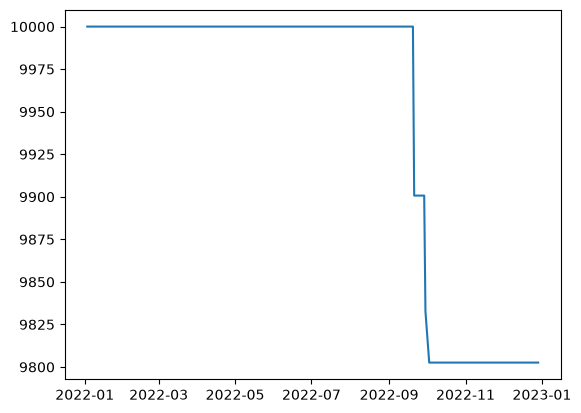

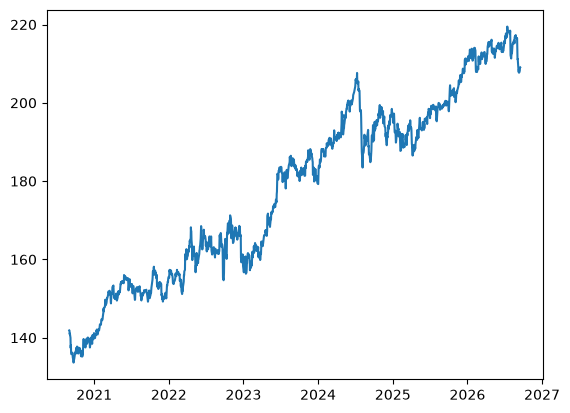

In [90]:
current_date = None
daily_list = []
daily_equity_list = []
for index in range(len(stats._equity_curve)):
    row = stats._equity_curve.iloc[index]
    if current_date is None:
        current_date = row.name
        first_hour = row.Equity
    else:
        if current_date.date() != row.name.date():
            daily_list.append(current_date)
            daily_equity_list.append(stats._equity_curve.iloc[index-1].Equity)
            current_date = None

print(len(daily_list))         
print(len(daily_equity_list)) 

plt.figure(1)
plt.plot(daily_list, daily_equity_list)

df_d1_price = df_d1_raw.loc['2020-9-1' : '2026-9-16']
plt.figure(2)
plt.plot(df_d1_price.index, df_d1_price['Close'])